# 04 - Spatial Clustering with Risk Overlay

## Alignment Notes
- Core question: Do grid cells form distinct risk clusters and which clusters should be prioritized?
- Based on what:
  - `dataset/cleaned_data/train.csv` (base crash data from notebook 01)
  - `dataset/cleaned_data/risk_scores.csv` (risk profile output from notebook 03)
- Unit of analysis: grid cell (must be consistent with notebook 03 profile grid).
- Output expected:
  - `dataset/cleaned_data/cluster_labels.csv` for notebook 05
- Run-order dependency: notebook 03 must complete and produce `risk_scores.csv` first.


In [34]:
# Placeholder-only notebook: implementation deferred.
from pathlib import Path
import pandas as pd
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA


## 1) Input continuity checks (TODO)


In [35]:
DATA_ROOT = Path('dataset') if Path('dataset').exists() else Path('../dataset')
CLEAN_DIR = DATA_ROOT / 'cleaned_data'

train_path = CLEAN_DIR / 'train.csv'
risk_path = CLEAN_DIR / 'risk_scores.csv'

print('train.csv', 'exists' if train_path.exists() else 'missing')
print('risk_scores.csv', 'exists' if risk_path.exists() else 'missing')

# TODO: when implementing, enforce required risk_scores columns:
required_risk_cols = [
    'grid_lat', 'grid_lon', 'risk_score', 'predicted_severe_rate',
    'crash_count', 'severe_count', 'rank'
]
print('required risk_scores columns:', required_risk_cols)


train.csv exists
risk_scores.csv exists
required risk_scores columns: ['grid_lat', 'grid_lon', 'risk_score', 'predicted_severe_rate', 'crash_count', 'severe_count', 'rank']


In [36]:
# — Empirical Bayes Condition Risk Estimation

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (12, 6)

DATA_ROOT = Path('dataset') if Path('dataset').exists() else Path('../dataset')
CLEAN_DIR = DATA_ROOT / 'cleaned_data'
IMAGE_DIR = Path('image/04_clustering') if Path('image').exists() else Path('../image/04_clustering')
IMAGE_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(name: str, dpi: int = 160) -> Path:
    out = IMAGE_DIR / name
    plt.savefig(out, dpi=dpi, bbox_inches='tight')
    print('Saved figure:', out.resolve())
    return out

# ------------------------------------------------------------
# Load base train/test
# ------------------------------------------------------------
train_base = pd.read_csv(CLEAN_DIR / 'train.csv')
test_base = pd.read_csv(CLEAN_DIR / 'test.csv')

for df in [train_base, test_base]:
    df['CRASH_DATE'] = pd.to_datetime(df['CRASH_DATE'], errors='coerce')

all_base = pd.concat([train_base, test_base], ignore_index=True)

print(f'Combined base rows: {len(all_base):,}')
print(f'Image output folder: {IMAGE_DIR.resolve()}')

# ------------------------------------------------------------
# Build profile base
# ------------------------------------------------------------
profile = all_base.copy()
profile = profile.dropna(subset=['LATITUDE', 'LONGITUDE']).copy()

# IMPORTANT: use one grid size consistently across notebooks
GRID_SIZE = 0.005

profile['grid_lat'] = (pd.to_numeric(profile['LATITUDE'], errors='coerce') / GRID_SIZE).round() * GRID_SIZE
profile['grid_lon'] = (pd.to_numeric(profile['LONGITUDE'], errors='coerce') / GRID_SIZE).round() * GRID_SIZE

# ------------------------------------------------------------
# Feature engineering consistent with EDA

def normalize_text(series):
    return (
        series.fillna('UNKNOWN')
              .astype(str)
              .str.upper()
              .str.strip()
              .replace({'': 'UNKNOWN'})
    )

# Weather bucket
weather_u = normalize_text(profile['WEATHER_CONDITION']) if 'WEATHER_CONDITION' in profile.columns else pd.Series('UNKNOWN', index=profile.index)
profile['weather_bucket'] = np.select(
    [
        weather_u.str.contains('CLEAR'),
        weather_u.str.contains('CLOUD'),
        weather_u.str.contains('RAIN|DRIZZLE'),
        weather_u.str.contains('SNOW|SLEET|ICE|FREEZING|BLOWING SNOW'),
        weather_u.str.contains('FOG|SMOKE|HAZE'),
        weather_u.eq('UNKNOWN')
    ],
    ['CLEAR', 'CLOUDY', 'RAIN', 'SNOW_ICE', 'LOW_VISIBILITY', 'UNKNOWN'],
    default='OTHER'
)

# Lighting bucket
lighting_u = normalize_text(profile['LIGHTING_CONDITION']) if 'LIGHTING_CONDITION' in profile.columns else pd.Series('UNKNOWN', index=profile.index)
profile['lighting_bucket'] = np.select(
    [
        lighting_u.str.contains('DAYLIGHT'),
        lighting_u.str.contains('DARKNESS, LIGHTED'),
        lighting_u.str.contains('DARKNESS') & ~lighting_u.str.contains('LIGHTED'),
        lighting_u.str.contains('DAWN|DUSK'),
        lighting_u.eq('UNKNOWN')
    ],
    ['DAYLIGHT', 'DARK_LIT', 'DARK_UNLIT', 'DAWN_DUSK', 'UNKNOWN'],
    default='OTHER'
)

# Time bucket
hour = pd.to_numeric(profile['CRASH_HOUR'], errors='coerce').fillna(12)
dow = pd.to_numeric(profile['CRASH_DAY_OF_WEEK'], errors='coerce').fillna(2)

profile['time_bucket'] = np.select(
    [
        dow.isin([1, 7]),
        hour.isin([7, 8, 9, 16, 17, 18]),
        hour.isin([20, 21, 22, 23, 0, 1, 2, 3, 4, 5]),
    ],
    ['WEEKEND', 'RUSH_HOUR', 'NIGHT'],
    default='DAYTIME'
)

# Speed context
speed_src = pd.to_numeric(profile['POSTED_SPEED_LIMIT'], errors='coerce')
profile['speed_context'] = np.select(
    [
        speed_src >= 40,
        speed_src >= 30,
        speed_src.notna()
    ],
    ['HIGH_SPEED', 'MID_SPEED', 'LOW_SPEED'],
    default='UNKNOWN'
)

# Binary structure / behavior indicators
if 'INTERSECTION_RELATED_I' in profile.columns:
    profile['is_intersection'] = (
        profile['INTERSECTION_RELATED_I']
        .fillna('N')
        .astype(str)
        .str.upper()
        .str.strip()
        .eq('Y')
        .astype(int)
    )
else:
    profile['is_intersection'] = 0

if 'HIT_AND_RUN_I' in profile.columns:
    profile['is_hit_and_run'] = (
        profile['HIT_AND_RUN_I']
        .fillna('N')
        .astype(str)
        .str.upper()
        .str.strip()
        .eq('Y')
        .astype(int)
    )
else:
    profile['is_hit_and_run'] = 0

if 'REPORT_TYPE' in profile.columns:
    profile['is_self_reported'] = (
        profile['REPORT_TYPE']
        .astype(str)
        .str.upper()
        .str.contains('NOT ON SCENE', na=False)
        .astype(int)
    )
else:
    profile['is_self_reported'] = 0

profile['is_night'] = hour.isin([20, 21, 22, 23, 0, 1, 2, 3, 4, 5]).astype(int)
profile['is_rush_hour'] = hour.isin([7, 8, 9, 16, 17, 18]).astype(int)
profile['is_weekend'] = dow.isin([1, 7]).astype(int)

# Optional roadway context
if 'TRAFFICWAY_TYPE' in profile.columns:
    t = normalize_text(profile['TRAFFICWAY_TYPE'])
    profile['is_four_way'] = (t == 'FOUR WAY').astype(int)
    profile['is_five_point'] = t.str.contains('FIVE POINT', na=False).astype(int)
    profile['is_y_intersection'] = t.str.contains('Y-INTERSECTION', na=False).astype(int)
    profile['is_t_intersection'] = t.str.contains('T-INTERSECTION', na=False).astype(int)
    profile['is_divided_road'] = t.str.contains('DIVIDED', na=False).astype(int)
else:
    profile['is_four_way'] = 0
    profile['is_five_point'] = 0
    profile['is_y_intersection'] = 0
    profile['is_t_intersection'] = 0
    profile['is_divided_road'] = 0

def roadway_context_label(row):
    if row['is_five_point'] == 1 or row['is_four_way'] == 1 or row['is_y_intersection'] == 1:
        return 'COMPLEX_INTERSECTION'
    if row['is_divided_road'] == 1:
        return 'DIVIDED_ROAD'
    return 'OTHER'

profile['roadway_context'] = profile.apply(roadway_context_label, axis=1)

# ------------------------------------------------------------
# Aggregate condition profiles
# NOTE: this is the condition-level risk table
# ------------------------------------------------------------
agg_cols = [
    'grid_lat', 'grid_lon',
    'weather_bucket', 'lighting_bucket',
    'time_bucket', 'speed_context'
]

agg = (
    profile.groupby(agg_cols, as_index=False)
           .agg(
               crash_count=('is_severe', 'size'),
               severe_count=('is_severe', 'sum'),
               severe_rate=('is_severe', 'mean'),
               avg_posted_speed=('POSTED_SPEED_LIMIT', 'mean'),
               pct_intersection=('is_intersection', 'mean'),
               pct_hit_run=('is_hit_and_run', 'mean'),
               pct_self_reported=('is_self_reported', 'mean'),
               pct_night=('is_night', 'mean'),
               pct_weekend=('is_weekend', 'mean'),
               pct_rush_hour=('is_rush_hour', 'mean'),
               pct_divided_road=('is_divided_road', 'mean')
           )
)

agg['severe_rate_pct'] = agg['severe_rate'] * 100

# ------------------------------------------------------------
# Empirical Bayes shrinkage
# ------------------------------------------------------------
global_rate = profile['is_severe'].mean()
alpha = 30

agg['predicted_severe_rate'] = (
    agg['severe_count'] + alpha * global_rate
) / (
    agg['crash_count'] + alpha
)

agg['predicted_severe_rate_pct'] = agg['predicted_severe_rate'] * 100

# Policy-oriented risk score
agg['risk_score'] = agg['predicted_severe_rate'] * np.log1p(agg['crash_count'])

print(f'Total condition profiles: {len(agg):,}')
print(f'Global severe rate: {global_rate*100:.3f}%')

display(
    agg[['crash_count', 'severe_count', 'severe_rate_pct', 'predicted_severe_rate_pct', 'risk_score']].describe()
)


Combined base rows: 328,495
Total condition profiles: 85,160
Global severe rate: 1.614%


,crash_count,severe_count,severe_rate_pct,predicted_severe_rate_pct,risk_score
count,85160.000000,85160.000000,85160.000000,85160.000000,85160.000000
mean,3.857386,0.062259,1.511550,1.614509,0.018787
std,8.563100,0.284399,9.909352,0.609521,0.017282
min,1.000000,0.000000,0.000000,0.230575,0.010827
25%,1.000000,0.000000,0.000000,1.513151,0.010827
50%,1.000000,0.000000,0.000000,1.561962,0.010827
75%,3.000000,0.000000,0.000000,1.561962,0.020341
max,225.000000,6.000000,100.000000,10.676686,0.290943


## 2) Clustering workflow (TODO)


Grid cells for clustering: 2,495


,grid_lat,grid_lon,n_profiles,total_crashes,total_severe,mean_predicted_risk,max_predicted_risk,mean_risk_score,max_risk_score,mean_speed,...,mean_pct_hit_run,mean_pct_self_reported,mean_pct_night,mean_pct_weekend,mean_pct_rush_hour,mean_pct_divided_road,severe_rate,severe_rate_pct,mean_predicted_risk_pct,max_predicted_risk_pct
0,41.645,-87.615,15,38,0,0.014982,0.015620,0.014882,0.028588,27.703704,...,0.674603,0.295767,0.4,0.266667,0.314286,0.814286,0.000000,0.000000,1.498223,1.561962
1,41.645,-87.610,1,1,0,0.015620,0.015620,0.010827,0.010827,30.000000,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,1.561962,1.561962
2,41.645,-87.605,1,1,0,0.015620,0.015620,0.010827,0.010827,30.000000,...,1.000000,0.000000,1.0,0.000000,0.000000,1.000000,0.000000,0.000000,1.561962,1.561962
3,41.645,-87.600,3,3,0,0.015620,0.015620,0.010827,0.010827,28.333333,...,0.666667,0.333333,0.0,0.000000,0.333333,1.000000,0.000000,0.000000,1.561962,1.561962
4,41.645,-87.560,3,3,1,0.026372,0.047878,0.018280,0.033186,28.333333,...,0.333333,0.333333,1.0,0.000000,0.000000,1.000000,0.333333,33.333333,2.637231,4.787769


,grid_lat,grid_lon,n_profiles,total_crashes,total_severe,mean_predicted_risk,max_predicted_risk,mean_risk_score,max_risk_score,mean_speed,...,mean_pct_hit_run,mean_pct_self_reported,mean_pct_night,mean_pct_weekend,mean_pct_rush_hour,mean_pct_divided_road,severe_rate,severe_rate_pct,mean_predicted_risk_pct,max_predicted_risk_pct
count,2495.000000,2495.000000,2495.000000,2495.000000,2495.000000,2495.000000,2495.000000,2495.000000,2495.000000,2495.000000,...,2495.000000,2495.000000,2495.000000,2495.000000,2495.000000,2495.000000,2495.000000,2495.000000,2495.000000,2495.000000
mean,41.839573,-87.683481,34.132265,131.661323,2.125050,0.016189,0.036225,0.017500,0.071976,27.464946,...,0.353363,0.491078,0.308505,0.292356,0.337123,0.569643,0.017207,1.720720,1.618900,3.622456
std,0.102649,0.072882,19.355663,134.756460,2.557517,0.001465,0.016081,0.003524,0.047076,2.535373,...,0.142346,0.139385,0.113346,0.104380,0.103955,0.168809,0.031353,3.135290,0.146494,1.608060
min,41.645000,-87.940000,1.000000,1.000000,0.000000,0.014256,0.015132,0.010827,0.010827,10.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.425558,1.513151
25%,41.750000,-87.730000,20.000000,40.000000,0.000000,0.015317,0.015620,0.015065,0.029571,26.428571,...,0.269626,0.425618,0.250000,0.250000,0.291886,0.471967,0.000000,0.000000,1.531698,1.561962
50%,41.835000,-87.680000,33.000000,95.000000,1.000000,0.015798,0.042406,0.017374,0.078134,27.388889,...,0.351092,0.500531,0.311508,0.291667,0.335366,0.571790,0.012346,1.234568,1.579821,4.240595
75%,41.935000,-87.635000,47.000000,182.000000,3.000000,0.016718,0.047878,0.019746,0.091091,28.273613,...,0.444562,0.572345,0.363203,0.333333,0.381842,0.666821,0.023007,2.300741,1.671847,4.787769
max,42.025000,-87.525000,146.000000,1178.000000,20.000000,0.047878,0.106767,0.033186,0.290943,55.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,100.000000,4.787769,10.676686


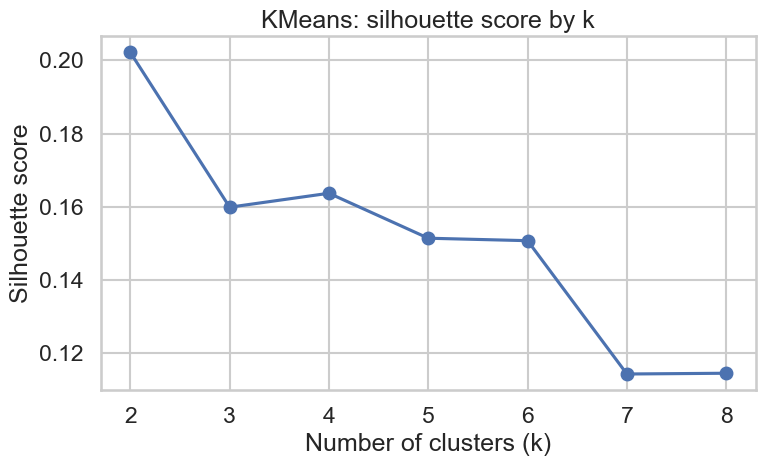

Best k by silhouette score: 2
KMeans cluster counts:
kmeans_cluster
0    1201
1    1294
Name: count, dtype: int64


,n_profiles,total_crashes,total_severe,mean_predicted_risk,max_predicted_risk,mean_risk_score,max_risk_score,mean_speed,mean_pct_intersection,mean_pct_hit_run,mean_pct_self_reported,mean_pct_night,mean_pct_weekend,mean_pct_rush_hour,mean_pct_divided_road,severe_rate_pct,mean_predicted_risk_pct
kmeans_cluster,,,,,,,,,,,,,,,,,
0,47.507,213.218,3.959,0.017,0.047,0.020,0.108,27.565,0.0,0.359,0.514,0.313,0.295,0.336,0.551,2.547,1.671
1,21.719,55.966,0.423,0.016,0.026,0.015,0.038,27.372,0.0,0.348,0.470,0.304,0.289,0.338,0.587,0.954,1.571


In [37]:
# TODO(C1): Step 4B — Collapse condition risk to grid-cell clustering table

grid_features = (
    agg.groupby(['grid_lat', 'grid_lon'], as_index=False)
       .agg(
           n_profiles=('risk_score', 'size'),
           total_crashes=('crash_count', 'sum'),
           total_severe=('severe_count', 'sum'),
           mean_predicted_risk=('predicted_severe_rate', 'mean'),
           max_predicted_risk=('predicted_severe_rate', 'max'),
           mean_risk_score=('risk_score', 'mean'),
           max_risk_score=('risk_score', 'max'),
           mean_speed=('avg_posted_speed', 'mean'),
           mean_pct_intersection=('pct_intersection', 'mean'),
           mean_pct_hit_run=('pct_hit_run', 'mean'),
           mean_pct_self_reported=('pct_self_reported', 'mean'),
           mean_pct_night=('pct_night', 'mean'),
           mean_pct_weekend=('pct_weekend', 'mean'),
           mean_pct_rush_hour=('pct_rush_hour', 'mean'),
           mean_pct_divided_road=('pct_divided_road', 'mean')
       )
)

grid_features['severe_rate'] = grid_features['total_severe'] / grid_features['total_crashes']
grid_features['severe_rate_pct'] = grid_features['severe_rate'] * 100
grid_features['mean_predicted_risk_pct'] = grid_features['mean_predicted_risk'] * 100
grid_features['max_predicted_risk_pct'] = grid_features['max_predicted_risk'] * 100

print(f'Grid cells for clustering: {len(grid_features):,}')
display(grid_features.head())
display(grid_features.describe())

# KMeans clustering
cluster_features = [
    'n_profiles',
    'total_crashes',
    'total_severe',
    'mean_predicted_risk',
    'max_predicted_risk',
    'mean_risk_score',
    'max_risk_score',
    'mean_speed',
    'mean_pct_intersection',
    'mean_pct_hit_run',
    'mean_pct_self_reported',
    'mean_pct_night',
    'mean_pct_weekend',
    'mean_pct_rush_hour',
    'mean_pct_divided_road'
]

X_cluster = grid_features[cluster_features].copy()
X_cluster = X_cluster.fillna(X_cluster.median(numeric_only=True))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# ------------------------------------------------------------
# Choose k with silhouette score
# ------------------------------------------------------------
k_values = range(2, 9)
sil_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    sil_scores.append(sil)

plt.figure(figsize=(8, 5))
plt.plot(list(k_values), sil_scores, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette score')
plt.title('KMeans: silhouette score by k')
plt.tight_layout()
save_fig('01_silhouette_scores.png')
plt.show()

best_k = list(k_values)[int(np.argmax(sil_scores))]
print(f'Best k by silhouette score: {best_k}')

# Fit final KMeans
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
grid_features['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

print('KMeans cluster counts:')
print(grid_features['kmeans_cluster'].value_counts().sort_index())

kmeans_summary = (
    grid_features.groupby('kmeans_cluster')[cluster_features + ['severe_rate_pct', 'mean_predicted_risk_pct']]
                 .mean()
                 .round(3)
)

display(kmeans_summary)


In [38]:
# DBSCAN clustering
# Try a few eps values
eps_values = [0.8, 1.0, 1.2, 1.5]
dbscan_results = []

for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=10)
    labels = db.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()

    dbscan_results.append({
        'eps': eps,
        'n_clusters': n_clusters,
        'n_noise_points': n_noise
    })

dbscan_results = pd.DataFrame(dbscan_results)
display(dbscan_results)

# Choose one eps manually after reviewing the table
chosen_eps = 1.2
dbscan = DBSCAN(eps=chosen_eps, min_samples=10)
grid_features['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

print('DBSCAN cluster counts:')
print(grid_features['dbscan_cluster'].value_counts().sort_index())

dbscan_summary = (
    grid_features.groupby('dbscan_cluster')[cluster_features + ['severe_rate_pct', 'mean_predicted_risk_pct']]
                 .mean()
                 .round(3)
)

display(dbscan_summary)

,eps,n_clusters,n_noise_points
0,0.8,0,2495
1,1.0,0,2495
2,1.2,5,2023
3,1.5,1,1004


DBSCAN cluster counts:
dbscan_cluster
-1    2023
 0     106
 1     346
 2       8
 3       4
 4       8
Name: count, dtype: int64


,n_profiles,total_crashes,total_severe,mean_predicted_risk,max_predicted_risk,mean_risk_score,max_risk_score,mean_speed,mean_pct_intersection,mean_pct_hit_run,mean_pct_self_reported,mean_pct_night,mean_pct_weekend,mean_pct_rush_hour,mean_pct_divided_road,severe_rate_pct,mean_predicted_risk_pct
dbscan_cluster,,,,,,,,,,,,,,,,,
-1,32.770,129.409,2.238,0.016,0.036,0.018,0.073,27.527,0.0,0.351,0.486,0.309,0.293,0.335,0.570,1.878,1.630
0,28.179,71.453,0.000,0.015,0.016,0.015,0.029,27.090,0.0,0.386,0.501,0.306,0.295,0.345,0.570,0.000,1.502
1,44.211,166.315,2.217,0.016,0.042,0.018,0.083,27.215,0.0,0.360,0.518,0.309,0.292,0.343,0.563,1.398,1.594
2,30.250,84.375,1.000,0.016,0.039,0.017,0.084,27.297,0.0,0.430,0.494,0.232,0.281,0.406,0.589,1.266,1.583
3,40.000,122.000,0.000,0.015,0.016,0.015,0.030,27.025,0.0,0.269,0.588,0.244,0.273,0.394,0.526,0.000,1.488
4,22.625,52.375,0.000,0.015,0.016,0.014,0.028,27.839,0.0,0.198,0.508,0.201,0.220,0.401,0.657,0.000,1.511


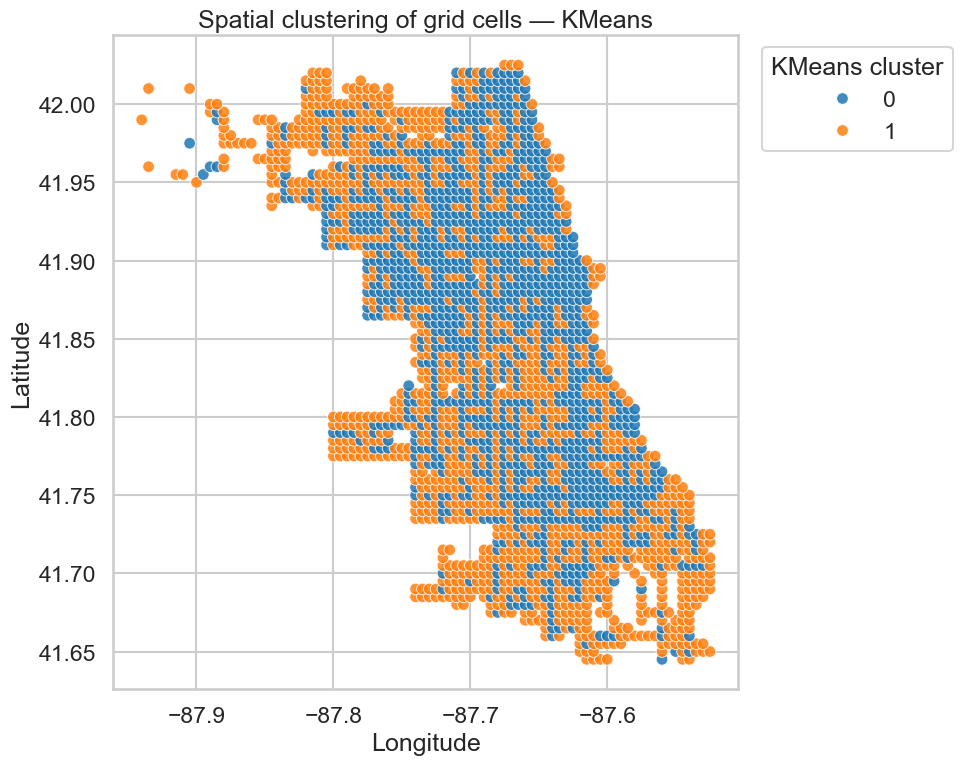

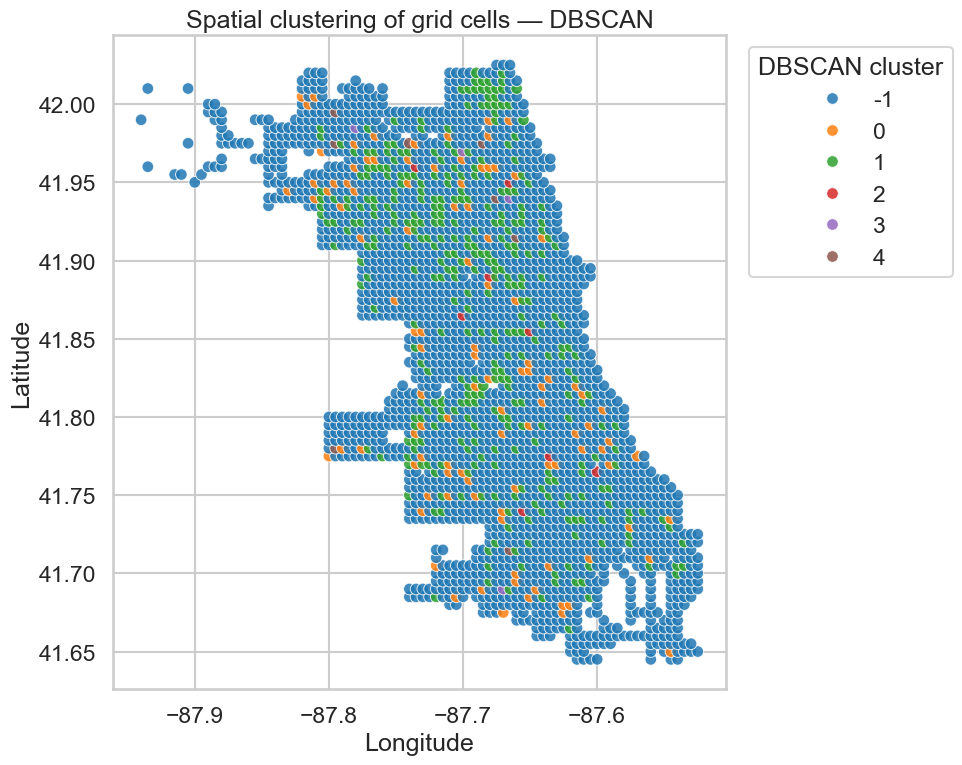

In [39]:
#Step 4E — Spatial visualization of clusters

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=grid_features,
    x='grid_lon',
    y='grid_lat',
    hue='kmeans_cluster',
    palette='tab10',
    s=70,
    alpha=0.85
)
plt.title('Spatial clustering of grid cells — KMeans')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='KMeans cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
save_fig('02_kmeans_spatial.png')
plt.show()

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=grid_features,
    x='grid_lon',
    y='grid_lat',
    hue='dbscan_cluster',
    palette='tab10',
    s=70,
    alpha=0.85
)
plt.title('Spatial clustering of grid cells — DBSCAN')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='DBSCAN cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
save_fig('03_dbscan_spatial.png')
plt.show()


## 3) Output contract for dashboard (TODO)


In [40]:
# Export cluster_labels.csv for notebook 05
high_risk_k = kmeans_summary['mean_predicted_risk_pct'].idxmax()

cluster_labels = grid_features[['grid_lat', 'grid_lon']].copy()
cluster_labels['cluster_kmeans'] = grid_features['kmeans_cluster']
cluster_labels['cluster_dbscan'] = grid_features['dbscan_cluster']
cluster_labels['is_high_risk_cluster'] = (grid_features['kmeans_cluster'] == high_risk_k).astype(int)
cluster_labels['crash_count'] = grid_features['total_crashes']
cluster_labels['severe_rate'] = grid_features['severe_rate']
cluster_labels['avg_risk_score'] = grid_features['mean_risk_score']

cluster_path = CLEAN_DIR / 'cluster_labels.csv'
cluster_labels.to_csv(cluster_path, index=False)

required_cluster_columns = [
    'grid_lat', 'grid_lon',
    'cluster_kmeans', 'cluster_dbscan',
    'is_high_risk_cluster',
    'crash_count', 'severe_rate',
    'avg_risk_score'
]

print('cluster_labels required columns:', required_cluster_columns)
print('Saved:', cluster_path.resolve())
display(cluster_labels.head())


cluster_labels required columns: ['grid_lat', 'grid_lon', 'cluster_kmeans', 'cluster_dbscan', 'is_high_risk_cluster', 'crash_count', 'severe_rate', 'avg_risk_score']


## 4) Handoff checklist for notebook 05 (TODO)


- `cluster_labels.csv` exists in `dataset/cleaned_data/`.
- Merge key compatibility confirmed: `grid_lat`, `grid_lon` match notebook 03 outputs.
- Cluster IDs are stable and non-null for most cells.
- High-risk cluster flag (`is_high_risk_cluster`) is available for policy filtering.
